# 🍄 **Mushroom Classification**

Although this dataset was originally contributed to the UCI Machine Learning repository nearly 30 years ago, mushroom hunting (otherwise known as "shrooming") is enjoying new peaks in popularity. Learn which features spell certain death and which are most palatable in this dataset of mushroom characteristics. And how certain can your model be?

This dataset includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family Mushroom drawn from The Audubon Society Field Guide to North American Mushrooms (1981). Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended. This latter class was combined with the poisonous one. The Guide clearly states that there is no simple rule for determining the edibility of a mushroom; no rule like "leaflets three, let it be'' for Poisonous Oak and Ivy.

## 📖 **1. Import libraries**

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

## 💾 **2. Downloading the dataset**

In [121]:
warnings.filterwarnings('ignore')

In [122]:
! pip install opendatasets

In [123]:
import opendatasets as od

In [124]:
od.download('https://www.kaggle.com/datasets/uciml/mushroom-classification/data')

Skipping, found downloaded files in "./mushroom-classification" (use force=True to force download)


In [125]:
df = pd.read_csv('/content/mushroom-classification/mushrooms.csv')

In [126]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

## 🥽 **3. Data visualization**

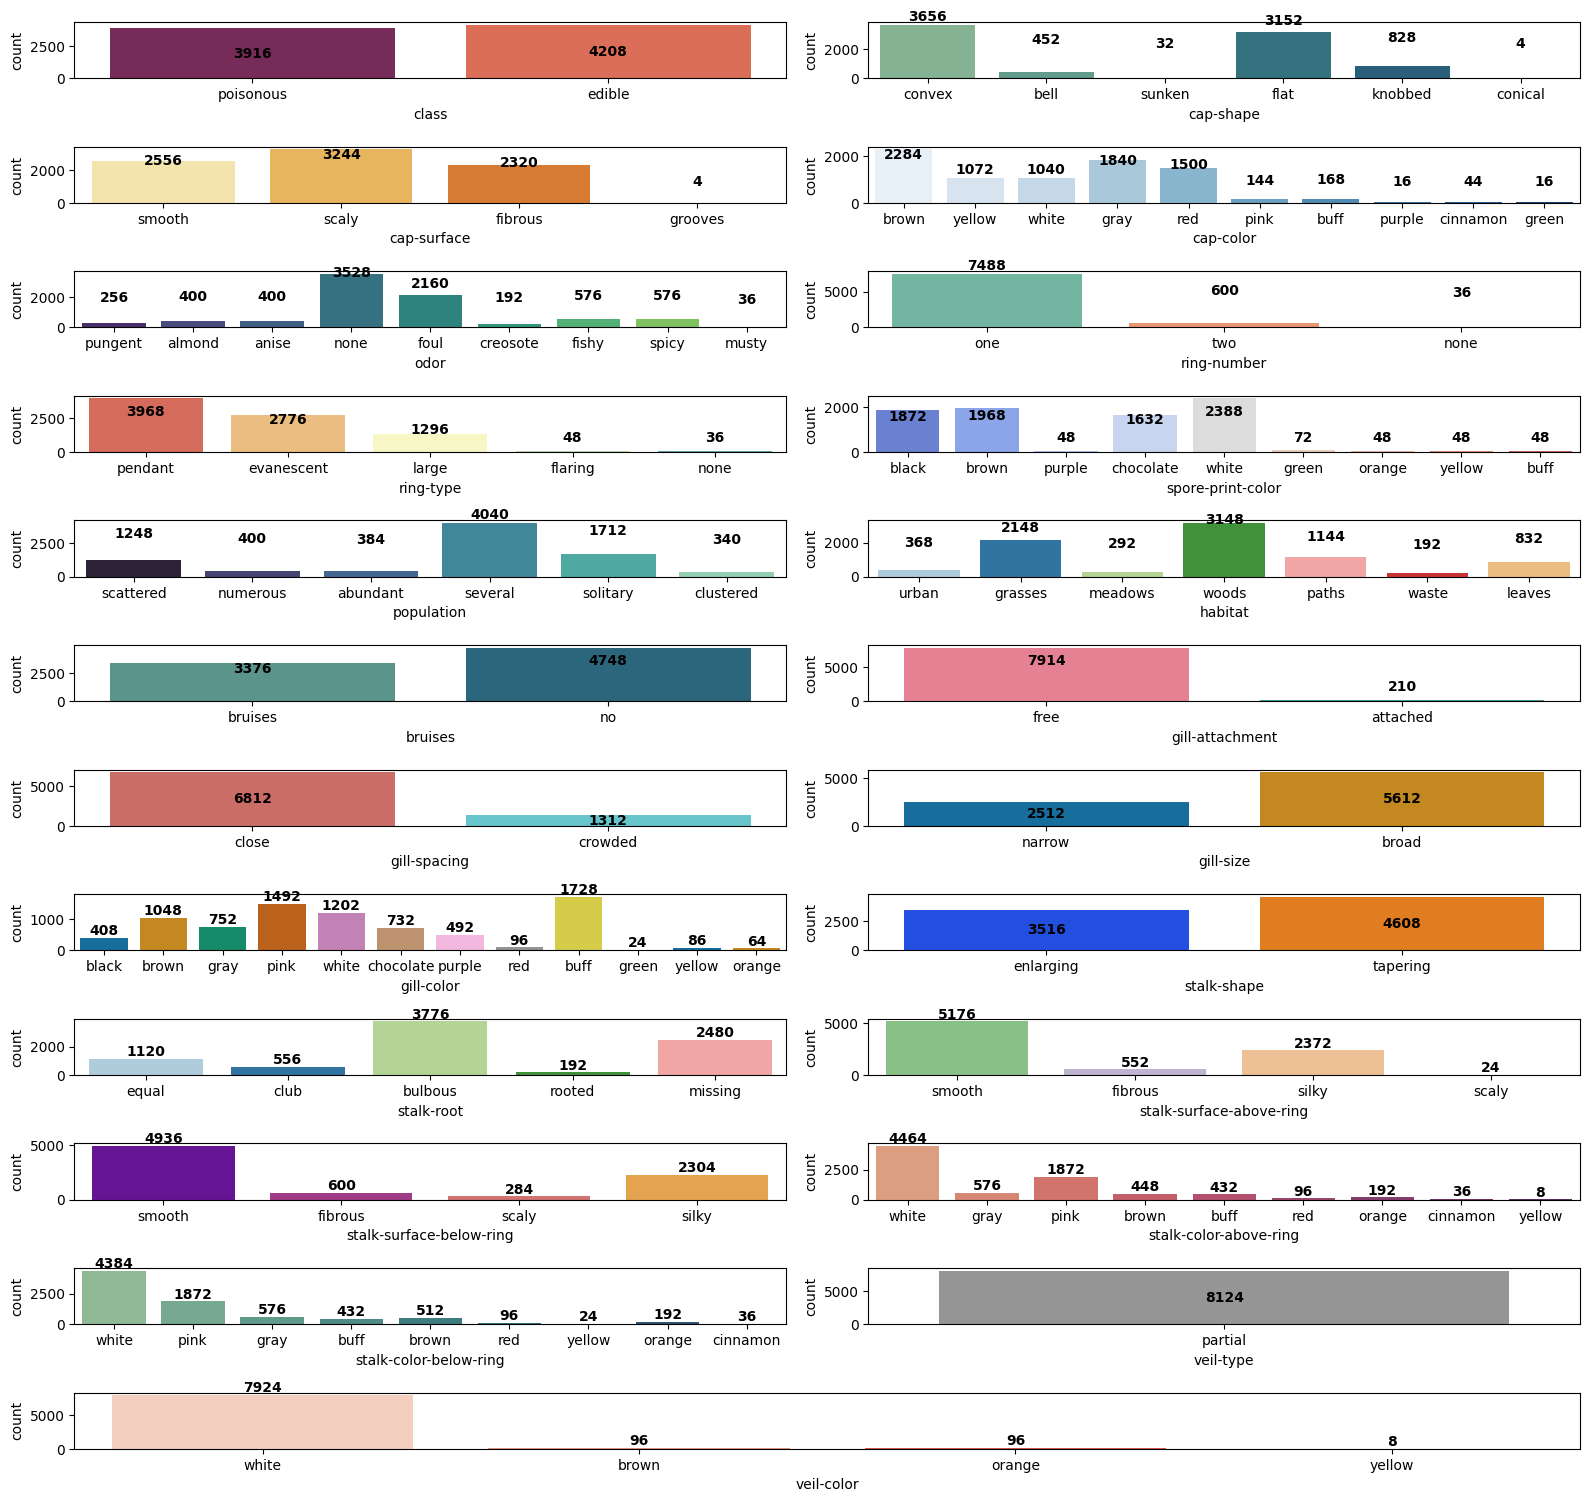

In [128]:
figure = plt.figure(figsize = (16, 15))

grid_spec = GridSpec(nrows = 12, ncols = 2, figure = figure)

axes_1 = figure.add_subplot(grid_spec[0, 0])
sns.countplot(data = df, x = 'class', hue = 'class', legend = False, palette = 'rocket', ax = axes_1)
axes_1.xaxis.set_ticklabels(['poisonous', 'edible'])
for container in axes_1.containers:
  axes_1.bar_label(container, label_type = 'center', fontweight = 'bold')

axes_2 = figure.add_subplot(grid_spec[0, 1])
sns.countplot(data = df, x = 'cap-shape', hue = 'cap-shape', legend = False, palette = 'crest', ax = axes_2)
axes_2.xaxis.set_ticklabels(['convex', 'bell', 'sunken', 'flat', 'knobbed', 'conical'])
for container in axes_2.containers:
  axes_2.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 25)

axes_3 = figure.add_subplot(grid_spec[1, 0])
sns.countplot(data = df, x = 'cap-surface', hue = 'cap-surface', legend = False, palette = 'YlOrBr', ax = axes_3)
axes_3.xaxis.set_ticklabels(['smooth', 'scaly', 'fibrous', 'grooves'])
for container in axes_3.containers:
  axes_3.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 15)

axes_4 = figure.add_subplot(grid_spec[1, 1])
sns.countplot(data = df, x = 'cap-color', hue = 'cap-color', legend = False, palette = 'Blues', ax = axes_4)
axes_4.xaxis.set_ticklabels(['brown', 'yellow', 'white', 'gray', 'red', 'pink', 'buff', 'purple', 'cinnamon', 'green'])
for container in axes_4.containers:
  axes_4.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 15)

axes_5 = figure.add_subplot(grid_spec[2, 0])
sns.countplot(data = df, x = 'odor', hue = 'odor', legend = False, palette = 'viridis', ax = axes_5)
axes_5.xaxis.set_ticklabels(['pungent', 'almond', 'anise', 'none', 'foul', 'creosote', 'fishy', 'spicy', 'musty'])
for container in axes_5.containers:
  axes_5.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 20)

axes_6 = figure.add_subplot(grid_spec[2, 1])
sns.countplot(data = df, x = 'ring-number', hue = 'ring-number', legend = False, palette = 'Set2', ax = axes_6)
axes_6.xaxis.set_ticklabels(['one', 'two', 'none'])
for container in axes_6.containers:
  axes_6.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 25)

axes_7 = figure.add_subplot(grid_spec[3, 0])
sns.countplot(data = df, x = 'ring-type', hue = 'ring-type', legend = False, palette = 'Spectral', ax = axes_7)
axes_7.xaxis.set_ticklabels(['pendant', 'evanescent', 'large', 'flaring', 'none'])
for container in axes_7.containers:
  axes_7.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 10)

axes_8 = figure.add_subplot(grid_spec[3, 1])
sns.countplot(data = df, x = 'spore-print-color', hue = 'spore-print-color', legend = False, palette = 'coolwarm', ax = axes_8)
axes_8.xaxis.set_ticklabels(['black', 'brown', 'purple', 'chocolate', 'white', 'green', 'orange', 'yellow', 'buff'])
for container in axes_8.containers:
  axes_8.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 10)

axes_9 = figure.add_subplot(grid_spec[4, 0])
sns.countplot(data = df, x = 'population', hue = 'population', legend = False, palette = 'mako', ax = axes_9)
axes_9.xaxis.set_ticklabels(['scattered', 'numerous', 'abundant', 'several', 'solitary', 'clustered'])
for container in axes_9.containers:
  axes_9.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 25)

axes_10 = figure.add_subplot(grid_spec[4, 1])
sns.countplot(data = df, x = 'habitat', hue = 'habitat', legend = False, palette = 'Paired', ax = axes_10)
axes_10.xaxis.set_ticklabels(['urban', 'grasses', 'meadows', 'woods', 'paths', 'waste', 'leaves'])
for container in axes_10.containers:
  axes_10.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 22)

axes_11 = figure.add_subplot(grid_spec[5, 0])
sns.countplot(data = df, x = 'bruises', hue = 'bruises', legend = False, palette = 'crest', ax = axes_11)
axes_11.xaxis.set_ticklabels(['bruises', 'no'])
for container in axes_11.containers:
  axes_11.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 10)

axes_12 = figure.add_subplot(grid_spec[5, 1])
sns.countplot(data = df, x = 'gill-attachment', hue = 'gill-attachment', legend = False, palette = 'husl', ax = axes_12)
axes_12.xaxis.set_ticklabels(['free', 'attached'])
for container in axes_12.containers:
  axes_12.bar_label(container, label_type = 'center', fontweight = 'bold', padding = 10)

axes_13 = figure.add_subplot(grid_spec[6, 0])
sns.countplot(data = df, x = 'gill-spacing', hue = 'gill-spacing', legend = False, palette = 'hls', ax = axes_13)
axes_13.xaxis.set_ticklabels(['close', 'crowded'])
for container in axes_13.containers:
  axes_13.bar_label(container, label_type = 'center', fontweight = 'bold')

axes_14 = figure.add_subplot(grid_spec[6, 1])
sns.countplot(data = df, x = 'gill-size', hue = 'gill-size', legend = False, palette = 'colorblind', ax = axes_14)
axes_14.xaxis.set_ticklabels(['narrow', 'broad'])
for container in axes_14.containers:
  axes_14.bar_label(container, label_type = 'center', fontweight = 'bold')

axes_15 = figure.add_subplot(grid_spec[7, 0])
sns.countplot(data = df, x = 'gill-color', hue = 'gill-color', legend = False, palette = 'colorblind', ax = axes_15)
axes_15.xaxis.set_ticklabels(['black', 'brown', 'gray', 'pink', 'white', 'chocolate', 'purple', 'red', 'buff', 'green', 'yellow', 'orange'])
for container in axes_15.containers:
  axes_15.bar_label(container, label_type = 'edge', fontweight = 'bold')

axes_16 = figure.add_subplot(grid_spec[7, 1])
sns.countplot(data = df, x = 'stalk-shape', hue = 'stalk-shape', legend = False, palette = 'bright', ax = axes_16)
axes_16.xaxis.set_ticklabels(['enlarging', 'tapering'])
for container in axes_16.containers:
  axes_16.bar_label(container, label_type = 'center', fontweight = 'bold')

axes_17 = figure.add_subplot(grid_spec[8, 0])
sns.countplot(data = df, x = 'stalk-root', hue = 'stalk-root', legend = False, palette = 'Paired', ax = axes_17)
axes_17.xaxis.set_ticklabels(['equal', 'club', 'bulbous', 'rooted', 'missing'])
for container in axes_17.containers:
  axes_17.bar_label(container, label_type = 'edge', fontweight = 'bold')

axes_18 = figure.add_subplot(grid_spec[8, 1])
sns.countplot(data = df, x = 'stalk-surface-above-ring', hue = 'stalk-surface-above-ring', legend = False, palette = 'Accent', ax = axes_18)
axes_18.xaxis.set_ticklabels(['smooth', 'fibrous', 'silky', 'scaly'])
for container in axes_18.containers:
  axes_18.bar_label(container, label_type = 'edge', fontweight = 'bold')

axes_19 = figure.add_subplot(grid_spec[9, 0])
sns.countplot(data = df, x = 'stalk-surface-below-ring', hue = 'stalk-surface-below-ring', legend = False, palette = 'plasma', ax = axes_19)
axes_19.xaxis.set_ticklabels(['smooth', 'fibrous', 'scaly', 'silky'])
for container in axes_19.containers:
  axes_19.bar_label(container, label_type = 'edge', fontweight = 'bold')

axes_20 = figure.add_subplot(grid_spec[9, 1])
sns.countplot(data = df, x = 'stalk-color-above-ring', hue = 'stalk-color-above-ring', legend = False, palette = 'flare', ax = axes_20)
axes_20.xaxis.set_ticklabels(['white', 'gray', 'pink', 'brown', 'buff', 'red', 'orange', 'cinnamon', 'yellow'])
for container in axes_20.containers:
  axes_20.bar_label(container, label_type = 'edge', fontweight = 'bold')

axes_21 = figure.add_subplot(grid_spec[10, 0])
sns.countplot(data = df, x = 'stalk-color-below-ring', hue = 'stalk-color-below-ring', legend = False, palette = 'crest', ax = axes_21)
axes_21.xaxis.set_ticklabels(['white', 'pink', 'gray', 'buff', 'brown', 'red', 'yellow', 'orange', 'cinnamon'])
for container in axes_21.containers:
  axes_21.bar_label(container, label_type = 'edge', fontweight = 'bold')

axes_22 = figure.add_subplot(grid_spec[10, 1])
sns.countplot(data = df, x = 'veil-type', hue = 'veil-type', legend = False, palette = 'Greys', ax = axes_22)
axes_22.xaxis.set_ticklabels(['partial'])
for container in axes_22.containers:
  axes_22.bar_label(container, label_type = 'center', fontweight = 'bold')

axes_23 = figure.add_subplot(grid_spec[11, :])
sns.countplot(data = df, x = 'veil-color', hue = 'veil-color', legend = False, palette = 'Reds', ax = axes_23)
axes_23.xaxis.set_ticklabels(['white', 'brown', 'orange', 'yellow'])
for container in axes_23.containers:
  axes_23.bar_label(container, label_type = 'edge', fontweight = 'bold')

plt.tight_layout()
plt.show()

- The number of edible and inedible mushrooms is almost the same.
- Almost all mushrooms have one ring.
- All mushrooms have a partial veil.
- Half of the mushrooms have a convex cap shape and the other half of the mushrooms almost all have a flat cap shape.
- The most common cap color is brown.
- One half of the mushrooms is odorless and almost all of the other half has a foul odor.
- Almost all mushrooms have a white veil.
- Almost all mushrooms have a free gill attachment.
- Top places where mushrooms grow:  
    1. Woods (~38%).  
    2. Grasses (~26%).
    3. Paths (~14%).
    4. Leaves (~10%).
    5. Urban (~4%).
    6. Meadows (~3%).
    7. Waste (~2%).
- The larger half of the mushrooms have a tapering stalk shape, and the smaller one has an enlarging stalk shape.

## 🤖 **4. Data transformation and separation**

In [129]:
df = pd.get_dummies(df, drop_first = True)

In [130]:
df.head()

,class_p,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,True,False,False,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
3,True,False,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


In [131]:
X = df.drop('class_p', axis = 1)

In [132]:
y = df['class_p']

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True)

## 👠 **5. Model training**

In [134]:
model = RandomForestClassifier(n_estimators = 150)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150)

In [135]:
prediction = model.predict(X_test)

## 🗿 **6. Confusion Matrix**

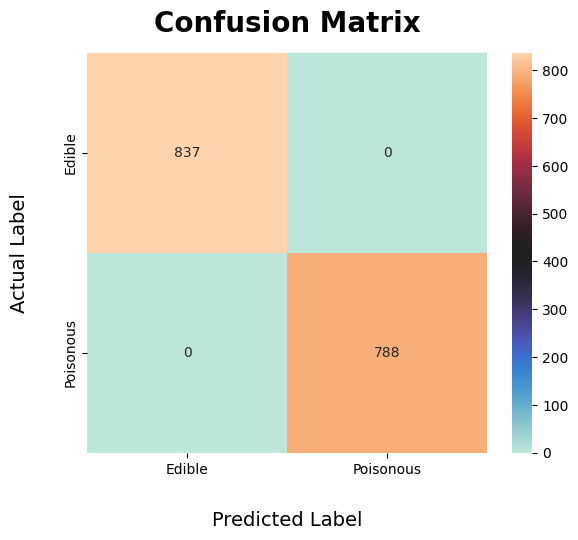

In [136]:
figure = plt.figure(figsize = (5, 4))

matrix_heat = confusion_matrix(y_test, prediction)

axes = figure.add_axes([0, 0, 1, 1])
sns.heatmap(matrix_heat, annot = True, fmt = 'd', cmap = 'icefire', axes = axes)
axes.xaxis.set_ticklabels(['Edible', 'Poisonous'])
axes.yaxis.set_ticklabels(['Edible', 'Poisonous'])
axes.set_xlabel('Predicted Label', labelpad = 25, fontsize = 14)
axes.set_ylabel('Actual Label', labelpad = 25, fontsize = 14)
axes.set_title('Confusion Matrix', fontweight = 'bold', pad = 15, fontsize = 20)

plt.show()

## 🏄🏻‍♂️ **7. Classification Report**

In [137]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       837
        True       1.00      1.00      1.00       788

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## 🌋 **8. AUC-ROC**

In [138]:
fpr, tpr, _ = roc_curve(y_test, prediction)

In [139]:
roc_auc = auc(fpr, tpr)

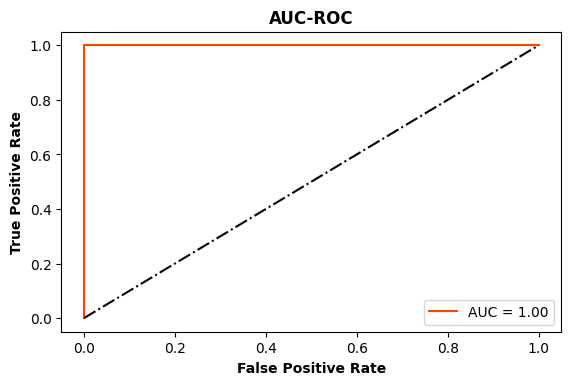

In [140]:
figure = plt.figure(figsize = (5, 3))

axes = figure.add_axes([0, 0, 1, 1])
axes.plot(fpr, tpr, label = f'AUC = {roc_auc:.2f}', color = '#FF4500')
axes.plot([0, 1], [0, 1], color = '#000000', linestyle = '-.')
axes.set_xlabel('False Positive Rate', fontweight = 'bold')
axes.set_ylabel('True Positive Rate', fontweight = 'bold')
axes.set_title('AUC-ROC', fontweight = 'bold')

plt.legend()
plt.show()

## 🌳 **9. Visualization of RandomForestClassifier**

In [141]:
! pip install supertree

In [142]:
from supertree import SuperTree
from sklearn.preprocessing import LabelEncoder

In [143]:
label_encoder = LabelEncoder()

In [144]:
y_train_encoded = label_encoder.fit_transform(y_train)

In [145]:
feature_names = X.columns.astype(str).tolist()

In [146]:
class_names = label_encoder.classes_.astype(str).tolist()

In [147]:
super_tree = SuperTree(
    model,
    X_train,
    y_train_encoded,
    feature_names,
    class_names
)

In [148]:
super_tree.show_tree()

Output hidden; open in https://colab.research.google.com to view.